In [1]:
# %% Zelle 1: Setup
import json, ast
from pathlib import Path
import numpy as np, pandas as pd, nibabel as nib
import matplotlib.pyplot as plt
import centroids as C

BASE      = Path(r"C:\Users\anmol\Documents\VSCode\application_BMDNow")
PROC      = BASE / "processed"
CENT_DIR  = BASE / "centroids"
DICE_TS   = BASE / "dice_totalseg_test.csv"     # ggf. Pfad anpassen
DICE_VS   = BASE / "dice_verse_test.csv"
CENT_DIR_TS = BASE / "centroids" / "totalseg"
CENT_DIR_VS = BASE / "centroids" / "verse"
VERSE_ROOTS = [BASE / "dataset-verse19training", BASE / "dataset-verse19test"]
LV = ["L1", "L2", "L3", "L4", "L5"]

ts = pd.read_csv(DICE_TS); vs = pd.read_csv(DICE_VS)
man = pd.read_csv(PROC / "manifest.csv")
print(len(ts), "TotalSeg-Testfaelle |", len(vs), "VerSe-Faelle")

15 TotalSeg-Testfaelle | 101 VerSe-Faelle


In [2]:
# %% Zelle 2: Part D – Dice-Tabelle pro Wirbel (beide Testsets)
def summary(df, name):
    r = {"Testset": name, "n": len(df)}
    for v in LV:
        r[v] = f"{df[v].mean():.3f} ± {df[v].std():.3f}"
    r["Mittel"] = f"{df[LV].mean(axis=1).mean():.3f}"
    return r

tab = pd.DataFrame([
    summary(ts, "TotalSeg (in-domain)"),
    summary(ts[ts.case != "s1385"], "TotalSeg ohne s1385"),
    summary(vs, "VerSe (out-of-domain)"),
])
display(tab)
print(tab.to_latex(index=False))          # direkt in den Bericht kopierbar

,Testset,n,L1,L2,L3,L4,L5,Mittel
0,TotalSeg (in-domain),15,0.861 ± 0.244,0.867 ± 0.238,0.900 ± 0.136,0.927 ± 0.037,0.899 ± 0.073,0.891
1,TotalSeg ohne s1385,14,0.922 ± 0.057,0.927 ± 0.044,0.935 ± 0.015,0.936 ± 0.013,0.906 ± 0.070,0.925
2,VerSe (out-of-domain),101,0.888 ± 0.104,0.882 ± 0.148,0.879 ± 0.167,0.859 ± 0.188,0.826 ± 0.201,0.853


\begin{tabular}{lrllllll}
\toprule
Testset & n & L1 & L2 & L3 & L4 & L5 & Mittel \\
\midrule
TotalSeg (in-domain) & 15 & 0.861 ± 0.244 & 0.867 ± 0.238 & 0.900 ± 0.136 & 0.927 ± 0.037 & 0.899 ± 0.073 & 0.891 \\
TotalSeg ohne s1385 & 14 & 0.922 ± 0.057 & 0.927 ± 0.044 & 0.935 ± 0.015 & 0.936 ± 0.013 & 0.906 ± 0.070 & 0.925 \\
VerSe (out-of-domain) & 101 & 0.888 ± 0.104 & 0.882 ± 0.148 & 0.879 ± 0.167 & 0.859 ± 0.188 & 0.826 ± 0.201 & 0.853 \\
\bottomrule
\end{tabular}



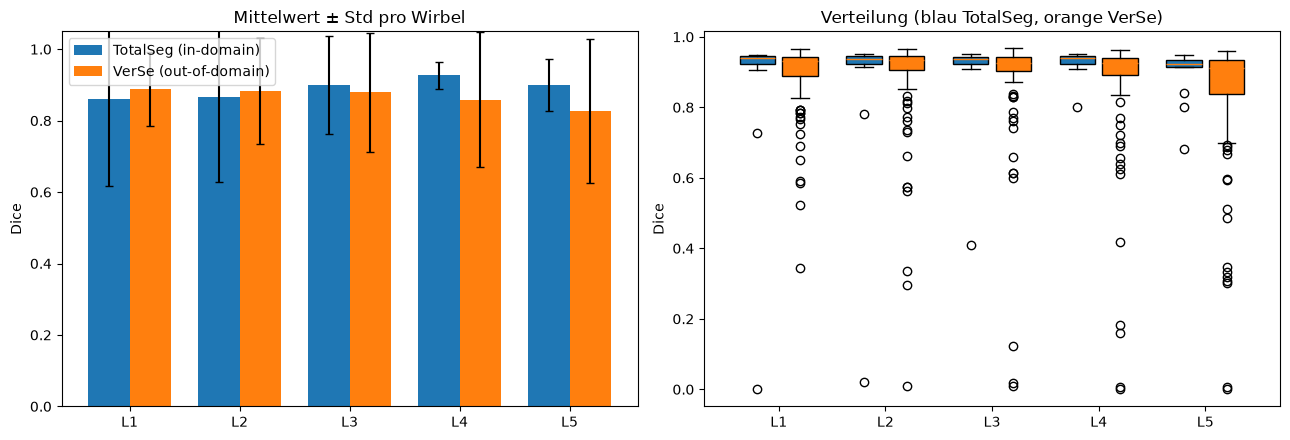

In [3]:
# %% Zelle 3: Plot Dice pro Wirbel, beide Datensaetze
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(5); w = 0.38
for i, (df, name) in enumerate([(ts, "TotalSeg (in-domain)"), (vs, "VerSe (out-of-domain)")]):
    ax[0].bar(x + (i - 0.5) * w, df[LV].mean(), w, yerr=df[LV].std(), capsize=3, label=name)
ax[0].set_xticks(x, LV); ax[0].set_ylim(0, 1.05); ax[0].set_ylabel("Dice"); ax[0].legend()
ax[0].set_title("Mittelwert ± Std pro Wirbel")

data = [ts[v].dropna() for v in LV] + [vs[v].dropna() for v in LV]
pos  = list(x - 0.2) + list(x + 0.2)
bp = ax[1].boxplot(data, positions=pos, widths=0.33, patch_artist=True)
for j, b in enumerate(bp["boxes"]):
    b.set_facecolor("C0" if j < 5 else "C1")
ax[1].set_xticks(x, LV); ax[1].set_ylabel("Dice"); ax[1].set_title("Verteilung (blau TotalSeg, orange VerSe)")
plt.tight_layout(); plt.savefig(BASE / "fig_dice.png", dpi=200); plt.show()

In [4]:
# %% Zelle 4: "Anything odd?" – vollstaendige vs. unvollstaendige Lendenwirbelsaeule
for df, name in [(ts, "TotalSeg"), (vs, "VerSe")]:
    df["mean"] = df[LV].mean(axis=1)
    df["komplett"] = df[LV].notna().all(axis=1)
    g = df.groupby("komplett")["mean"].agg(["mean", "std", "count"]).round(3)
    print(f"\n{name}: Dice nach Vollstaendigkeit L1-L5 in der Ground Truth\n{g}")

print("\nVerSe – schlechteste 8 Faelle:")
display(vs.sort_values("mean").head(8)[["case"] + LV + ["mean"]].round(3))


TotalSeg: Dice nach Vollstaendigkeit L1-L5 in der Ground Truth
           mean    std  count
komplett                     
True      0.891  0.136     15

VerSe: Dice nach Vollstaendigkeit L1-L5 in der Ground Truth
           mean    std  count
komplett                     
False     0.612  0.293     14
True      0.892  0.083     87

VerSe – schlechteste 8 Faelle:


,case,L1,L2,L3,L4,L5,mean
58,sub-verse113,NaN,0.011,0.009,0.000,0.000,0.005
74,sub-verse146,NaN,NaN,0.018,0.183,0.318,0.173
20,sub-verse048,NaN,0.336,0.123,0.159,0.347,0.241
2,sub-verse006,NaN,NaN,NaN,0.657,0.302,0.479
42,sub-verse083,0.937,0.930,0.599,0.007,0.007,0.496
59,sub-verse119,0.523,NaN,NaN,NaN,NaN,0.523
72,sub-verse144,0.592,0.561,0.658,0.417,0.593,0.564
3,sub-verse007,0.848,0.295,0.612,NaN,NaN,0.585


In [5]:
def load_cents(d):
    rows = []
    for f in sorted(Path(d).glob("*_centroids.json")):
        j = json.loads(f.read_text())
        row = {"case": j["case_id"]}
        for v, c in j["centroids"].items():
            row[f"{v}_x"], row[f"{v}_y"], row[f"{v}_z"] = c
        rows.append(row)
    return pd.DataFrame(rows)

cen_ts = load_cents(CENT_DIR_TS); cen_ts["dataset"] = "totalseg"
cen_vs = load_cents(CENT_DIR_VS); cen_vs["dataset"] = "verse"
cen    = pd.concat([cen_ts, cen_vs], ignore_index=True)
def order_ok(r):
    zs = [r[f"{v}_z"] for v in LV if f"{v}_z" in r and pd.notna(r[f"{v}_z"])]
    return all(a > b for a, b in zip(zs, zs[1:]))
cen["order_ok"] = cen.apply(order_ok, axis=1)
print(cen.groupby("dataset")["order_ok"].agg(["sum", "count"]))
print("Faelle mit falscher Reihenfolge:", cen.loc[~cen.order_ok, "case"].tolist())

# Abstand benachbarter Zentroide (Wirbelhoehe inkl. Bandscheibe, erwartet grob 30-40 mm)
d = []
for _, r in cen.iterrows():
    for a, b in zip(LV, LV[1:]):
        if pd.notna(r.get(f"{a}_x")) and pd.notna(r.get(f"{b}_x")):
            d.append(np.linalg.norm([r[f"{a}_{c}"] - r[f"{b}_{c}"] for c in "xyz"]))
print(f"Abstand Nachbar-Zentroide: Median {np.median(d):.1f} mm, 5–95 %: {np.percentile(d, 5):.1f}–{np.percentile(d, 95):.1f} mm")

          sum  count
dataset             
totalseg   84     95
verse      88    101
Faelle mit falscher Reihenfolge: ['s0223', 's0573', 's0866', 's1082', 's1167', 's1353', 's1370', 's1385', 's1389', 's1401', 's1405', 'sub-verse006', 'sub-verse007', 'sub-verse048', 'sub-verse050', 'sub-verse059', 'sub-verse075', 'sub-verse081', 'sub-verse085', 'sub-verse119', 'sub-verse146', 'sub-verse402_split-verse251', 'sub-verse416_split-verse279', 'sub-verse417_split-verse277']
Abstand Nachbar-Zentroide: Median 34.0 mm, 5–95 %: 23.4–53.0 mm


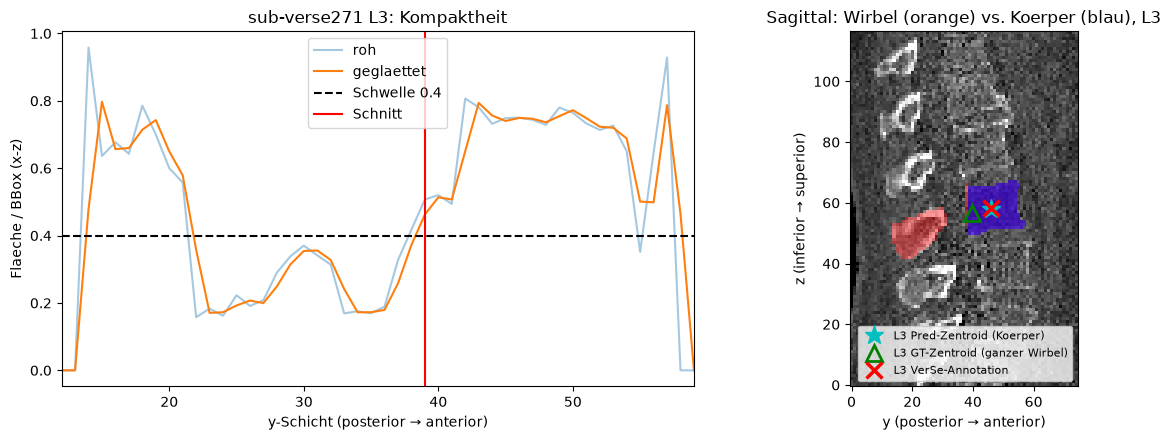

Pred-Koerper vs. GT-Maske:      13.3 mm
Pred-Koerper vs. VerSe-Annot.:  126.8 mm
GT-Maske     vs. VerSe-Annot.:  127.0 mm


In [31]:
# %% Zelle 6: Part C – Methode sichtbar machen (Kompaktheitsprofil + Schnitt)
case, k = "sub-verse271", 3
pred_arr = np.asanyarray(nib.load(BASE / "preds" / "verse" / case / "pred.nii.gz").dataobj)
img_nib  = nib.load(PROC / "verse" / case / "image.nii.gz")
img      = img_nib.get_fdata()
affine   = img_nib.affine
m        = pred_arr == k

prof   = np.array([C.compactness_profile(m[:, y, :]) for y in range(m.shape[1])])
smooth = np.convolve(prof, np.ones(C.SMOOTH_WINDOW) / C.SMOOTH_WINDOW, mode="same")
cut    = C.find_body_cut(m)
body   = C.vertebra_body_mask(m)
xc     = int(np.argwhere(m)[:, 0].mean())

def world_to_yz(w, aff):
    v = np.linalg.inv(aff) @ np.append(w, 1)
    return float(v[1]), float(v[2])

# 1. Zentroid Prediction (Koerper) aus JSON
cent_pred_mm = None
cent_json = Path(CENT_DIR_VS) / f"{case}_centroids.json"
if cent_json.exists():
    val = json.loads(cent_json.read_text())["centroids"].get(LV[k-1])
    if val is not None:
        cent_pred_mm = np.array(val)

# 2. Zentroid GT-Maske (ganzer Wirbel, Mittelwert aller Voxel)
cent_gt_mm = None
lab_p = PROC / "verse" / case / "label.nii.gz"
if lab_p.exists():
    lab_arr = np.asanyarray(nib.load(lab_p).dataobj)
    gt_mask = lab_arr == k
    if gt_mask.any():
        vox_gt     = np.argwhere(gt_mask).astype(float).mean(0)
        cent_gt_mm = (affine @ np.append(vox_gt, 1))[:3]

# 3. VerSe-Annotation aus ctd.json (annot. Zentroid im Original-CT-Raum)
cent_verse_mm = None
label_verse = 20 + k - 1   # L1=20, L2=21, L3=22 ...
for root in VERSE_ROOTS:
    ct_cands  = list((root / "rawdata").glob(f"*/{case}_ct.nii.gz"))
    ctd_cands = list((root / "derivatives").glob(f"*/{case}_seg-subreg_ctd.json"))
    if ct_cands and ctd_cands:
        img_orig = nib.load(ct_cands[0])
        ctd_raw  = json.loads(ctd_cands[0].read_text())
        for d in ctd_raw:
            if d.get("label") == label_verse:
                vox_orig      = np.array([d["X"], d["Y"], d["Z"]])
                cent_verse_mm = (img_orig.affine @ np.append(vox_orig, 1))[:3]
        break

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ys = np.where(m.any((0, 2)))[0]

ax[0].plot(prof,   alpha=.4, label="roh")
ax[0].plot(smooth, label="geglaettet")
ax[0].axhline(C.COMPACTNESS_THRESH, ls="--", c="k",
              label=f"Schwelle {C.COMPACTNESS_THRESH}")
if cut is not None:
    ax[0].axvline(cut, c="r", label="Schnitt")
ax[0].set_xlim(ys.min() - 2, ys.max() + 2)
ax[0].set_xlabel("y-Schicht (posterior → anterior)")
ax[0].set_ylabel("Flaeche / BBox (x-z)")
ax[0].legend()
ax[0].set_title(f"{case} {LV[k-1]}: Kompaktheit")

ax[1].imshow(img[xc].T, cmap="gray", origin="lower")
ax[1].imshow(np.ma.masked_where(~m[xc].T,    np.ones_like(m[xc].T,    float)),
             cmap="autumn", alpha=.4, origin="lower")
ax[1].imshow(np.ma.masked_where(~body[xc].T, np.ones_like(body[xc].T, float)),
             cmap="winter", alpha=.6, origin="lower")

if cent_pred_mm is not None:
    py, pz = world_to_yz(cent_pred_mm, affine)
    ax[1].plot(py, pz, "c*", ms=14, label=f"{LV[k-1]} Pred-Zentroid (Koerper)")

if cent_gt_mm is not None:
    gy, gz = world_to_yz(cent_gt_mm, affine)
    ax[1].plot(gy, gz, "g^", ms=11, markerfacecolor="none",
               markeredgewidth=2, label=f"{LV[k-1]} GT-Zentroid (ganzer Wirbel)")

if cent_verse_mm is not None:
    vy, vz = world_to_yz(cent_verse_mm, affine)
    ax[1].plot(vy, vz, "rx", ms=12, markeredgewidth=2.5,
               label=f"{LV[k-1]} VerSe-Annotation")

ax[1].legend(loc="lower right", fontsize=8)
ax[1].set_title(f"Sagittal: Wirbel (orange) vs. Koerper (blau), {LV[k-1]}")
ax[1].set_xlabel("y (posterior → anterior)")
ax[1].set_ylabel("z (inferior → superior)")
plt.tight_layout()
plt.savefig(BASE / "fig_body_cut.png", dpi=200)
plt.show()

# Abstände
if cent_pred_mm is not None and cent_gt_mm is not None:
    print(f"Pred-Koerper vs. GT-Maske:      {np.linalg.norm(cent_pred_mm - cent_gt_mm):.1f} mm")
if cent_pred_mm is not None and cent_verse_mm is not None:
    print(f"Pred-Koerper vs. VerSe-Annot.:  {np.linalg.norm(cent_pred_mm - cent_verse_mm):.1f} mm")
if cent_gt_mm is not None and cent_verse_mm is not None:
    print(f"GT-Maske     vs. VerSe-Annot.:  {np.linalg.norm(cent_gt_mm - cent_verse_mm):.1f} mm")